In [1]:
import torch
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
import pyvista as pv
from pathlib import Path
import imageio.v2 as imageio
import numpy as np
from PIL import Image
pv.start_xvfb()

%load_ext autoreload
%autoreload 2
# from help_functions.make_conv_2d_torch import make_conv_2d_torch
from help_functions.make_conv_3d_torch import make_conv_3d_torch
from help_functions.morph_fill import morph_fill_fast
# from help_functions.Sub_AT_torch import Sub_AT_torch
# from help_functions.Sub_A_torch import Sub_A_torch
# from help_functions.solve_least_squares_subdivision import solve_least_squares_subdivision
from help_functions.plot_subdivision_points import plot_subdivision_points
# from help_functions.solve_least_squares_subdivision import apply_C
from help_functions.shadows_visual import shadows_visual, points_visual
from help_functions.fast_optimization import (Sub_A_fast, 
                                              apply_A_j,
                                              apply_AT_j,
                                              apply_C_j,
                                            #   Sub_AT_fast, 
                                            #   solve_least_squares_subdivision_fast,
                                              solve_least_squares_subdivision_CG,
                                              build_kernel)
from help_functions.spherical_kernel_3d import spherical_kernel_3d

# from help_functions.fast_optimization import *


from help_functions.make_html_visual import make_html_visual
from help_functions.make_scatter_visual import make_scatter_visual, make_scatter_with_plane

# from IPython.display import HTML
# import kaleido
# import plotly.io as pio
# import open3d as o3d


In [ ]:

subfolder = 'plank'
camera_position = (750,200,150)
slice_coord = 180
input_koef = 1
model_path = './models/MaxPlankWithNormals.xyz'

In [ ]:
'''
Здесь импортируем изображение, центрируем и поворачиваем при надобности
'''
raw_data = np.loadtxt(model_path)[:, :3].reshape(-1)
print("Количество точек во входном файле: ", len(raw_data))

int_cast_data = np.trunc(raw_data*input_koef).astype(int).reshape(-1, 3)

shifted = (int_cast_data - int_cast_data.min(axis=0) + np.array([10,10,10]))
sizes = (int_cast_data.max(axis=0) - int_cast_data.min(axis=0) + np.array([20,20, 20])).astype(int)
model_tensor_3D = torch.zeros(tuple(sizes), dtype=torch.float16)

model_tensor_3D[shifted[:, 0], shifted[:, 1], shifted[:, 2]] = 1

model_tensor_3D_rotated_90 = torch.rot90(input = model_tensor_3D, k=1, dims=(1, 2))
model_tensor_3D_rotated_90 = torch.rot90(input = model_tensor_3D_rotated_90, k=3, dims=(0, 1))

print (f"Количество точек {len(torch.argwhere(model_tensor_3D != 0))}")

model_tensor_3D = model_tensor_3D_rotated_90


Количество точек во входном файле:  450006
Количество точек 149546


In [83]:
shift = 1
make_html_visual(model_tensor_3D[::shift, ::shift, ::shift], name="model_raw_points_visual", subfolder=subfolder)

Файл сохранен в ./plank/htmls/model_raw_points_visual.html


In [102]:
'''
Здесь утолщаем границы
'''
radius = 3
kernel_3D = spherical_kernel_3d(radius)
model_conv_result_3D = make_conv_3d_torch(source=model_tensor_3D, kernel=kernel_3D)



/home/alexander/DIPLOM/.diplom3d/lib/python3.8/site-packages/pyvista/core/utilities/points.py:55: UserWarning:

Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.

/home/alexander/DIPLOM/.diplom3d/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning:

Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.



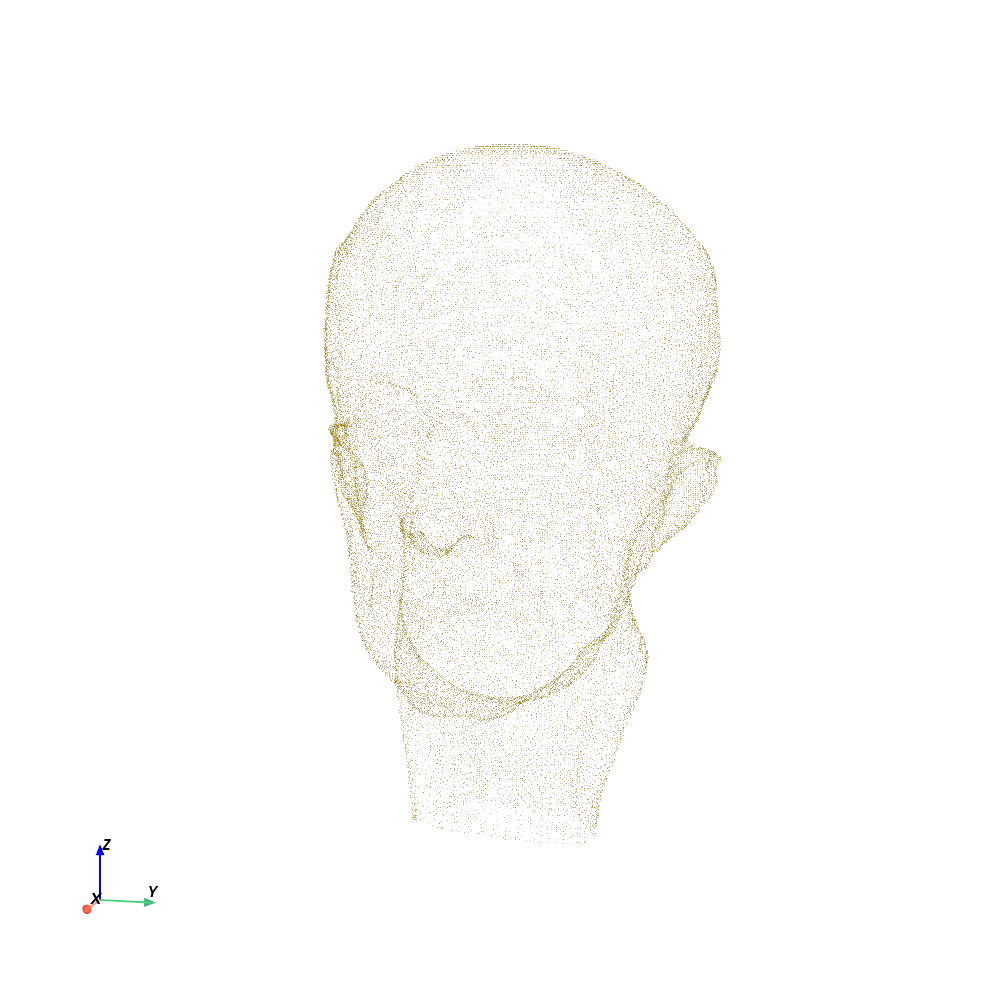

Изображение сохранено в plank/plank_model_dots.png


In [ ]:
points_visual(input_tensor=model_tensor_3D, 
                name=f"{subfolder}_model_dots", 
                subfolder=subfolder,
                threshold=0.5, 
                point_size=1.01,
                camera_position=camera_position
               )

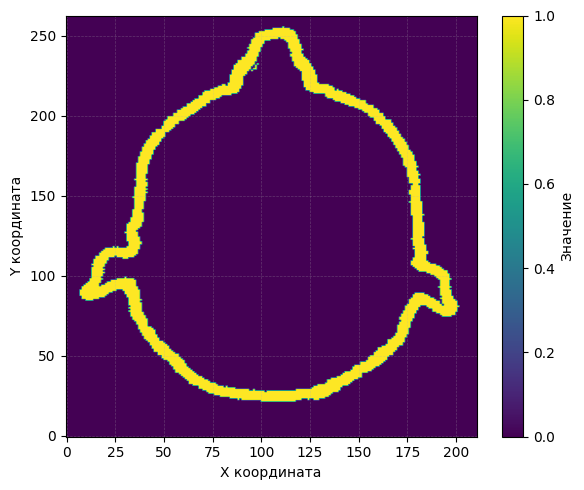

In [131]:
plt.figure(figsize=(6, 5))
    
plt.imshow(model_conv_result_3D[:,:, slice_coord], 
           cmap='viridis', 
           aspect='auto',
           origin='lower')  

plt.colorbar(label='Значение')
plt.xlabel('X координата')
plt.ylabel('Y координата')

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'./{subfolder}/{subfolder}-2d-slice-after-conv.png')
plt.show()


In [104]:

model_conv_result_3D_filled = model_conv_result_3D.clone()
for layer in range (model_conv_result_3D.shape[2]):
    model_conv_result_3D_filled[:,:,layer] = morph_fill_fast(model_conv_result_3D_filled[:,:,layer])



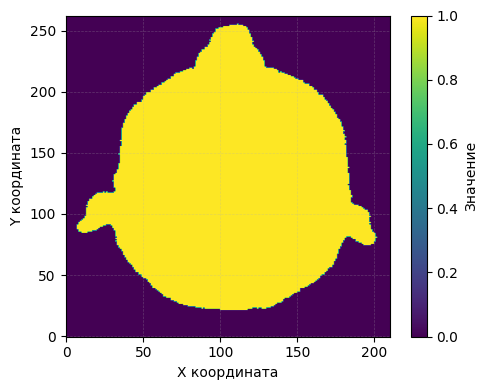

In [132]:
plt.figure(figsize=(5, 4))
    
plt.imshow(model_conv_result_3D_filled[:, :, slice_coord], 
           cmap='viridis', 
           aspect='auto',
           origin='lower')  

plt.colorbar(label='Значение')
plt.xlabel('X координата')
plt.ylabel('Y координата')

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'./{subfolder}/{subfolder}_slice_conv_filled.png')
plt.show()

/home/alexander/DIPLOM/.diplom3d/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning:

Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.



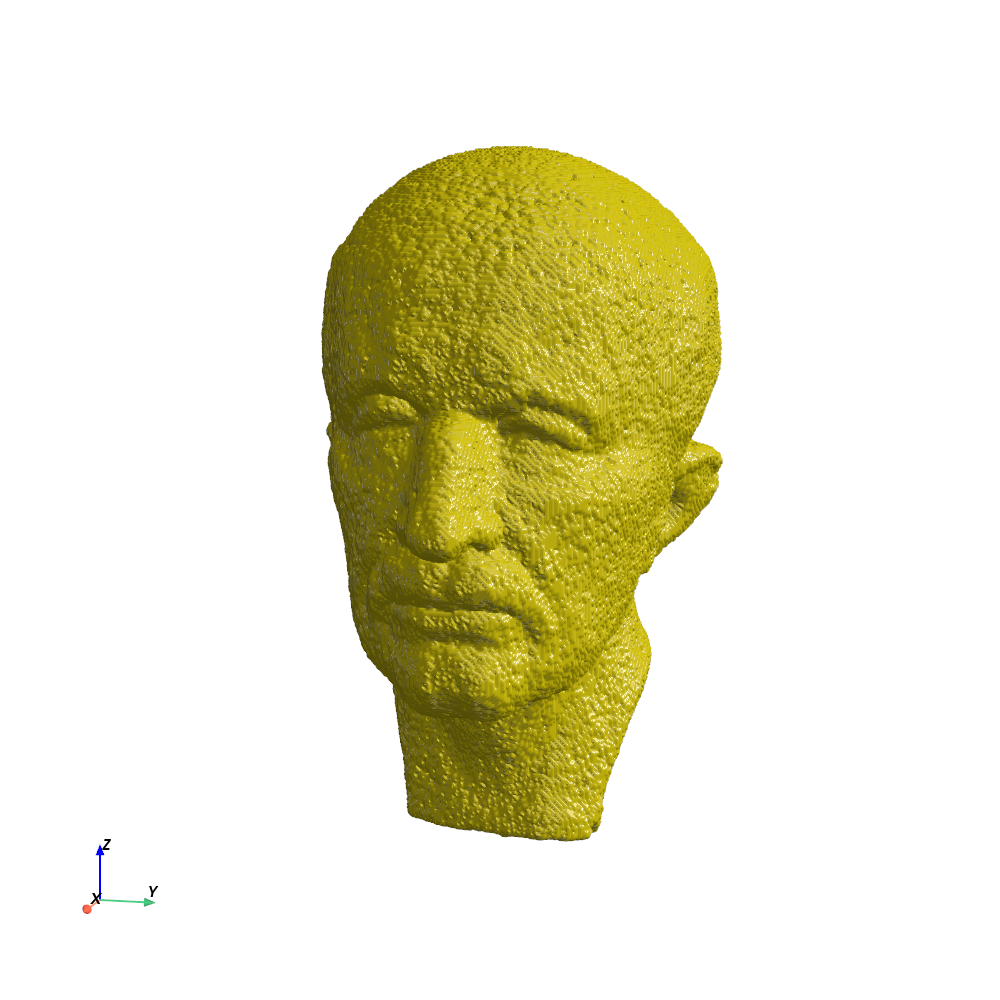

Изображение сохранено в plank/plank_voxel_1.png


In [125]:
shadows_visual(input_tensor=model_conv_result_3D_filled, 
                name=f"plank_voxel_{input_koef}", 
                subfolder=subfolder,
                level=0.3,
                ambient = 0.3,
                diffuse = 0.8,
                specular = 1,
                specular_power = 30,
                roughness = 0.3,
                # window_size = (800,800),
                camera_position=camera_position,
                light_position=(50,850,500)
               )

In [ ]:
# output_gif_path = Path("./gifs/model/filled/result.gif")
# images = [imageio.imread(frame_path) for frame_path in saved_frames[::4]]
# imageio.mimsave(output_gif_path, images, duration=duration, loop=0)

# print(f"GIF сохранена в: {output_gif_path}")

GIF сохранена в: gifs/budda/filled/result.gif


In [43]:
def nearest_multiple_of_n(x, n):
    return n * math.ceil(x / n)

nearest_multiple_of_n(713, 8)

720

In [44]:
def pad_to_multiple_centered(x: torch.Tensor, j: int):
    m = 2 ** j
    d0, d1, d2 = x.shape

    def compute_pad(d):
        new_d = ((d + m - 1) // m) * m
        p = new_d - d
        left = p // 2
        right = p - left
        return left, right

    p0l, p0r = compute_pad(d0)
    p1l, p1r = compute_pad(d1)
    p2l, p2r = compute_pad(d2)

    pads = (p2l, p2r, p1l, p1r, p0l, p0r)

    x_padded = F.pad(x, pads)

    return x_padded, (p0l, p0r, p1l, p1r, p2l, p2r)

In [ ]:
# mask = build_kernel(torch.tensor([1 / 4, 3 / 4, 3 / 4, 1 / 4], dtype=torch.float32), dim = 3)
# j = 2
# x_pad, pads = pad_to_multiple_centered(model_conv_result_3D_filled, j)
# test = apply_AT_j(x_pad, mask, j)
# print("shape after downsampling", test.shape)
# print("multiplied shape", np.array(test.shape)*np.power(2, j))
# print("original shape", model_conv_result_3D_filled.shape)

shape after downsampling torch.Size([98, 98, 229])
multiplied shape [392 392 916]
original shape torch.Size([385, 386, 912])


In [ ]:
# after_ups = apply_A_j(test, mask, j)
# print("shape after upsampling", after_ups.shape)
# # print("multiplied shape", np.array(test.shape)*np.power(2, j))
# print("original shape", model_conv_result_3D_filled.shape)

shape after upsampling torch.Size([393, 393, 913])
original shape torch.Size([385, 386, 912])


In [122]:
# mask = torch.tensor([1 / 4, 3 / 4, 3 / 4, 1 / 4], dtype=torch.float32)
mask = torch.tensor([1 / 8, 4 / 8, 6 / 8, 4 / 8, 1 / 8], dtype=torch.float32)

j = 2
gd_iter = 2
Z = model_conv_result_3D_filled
Z_pad, pads = pad_to_multiple_centered(Z, j)
x0 = solve_least_squares_subdivision_CG(Z, mask, j = j, tol = 1e-1, max_iter=gd_iter)


CG ITER 0: residual = 1.332903e+03
CG ITER 1: residual = 6.934462e+02


In [12]:
print("original shape", Z_pad.shape)
print("start sequence shape", x0.shape)

original shape torch.Size([304, 304, 720])
start sequence shape torch.Size([39, 39, 90])


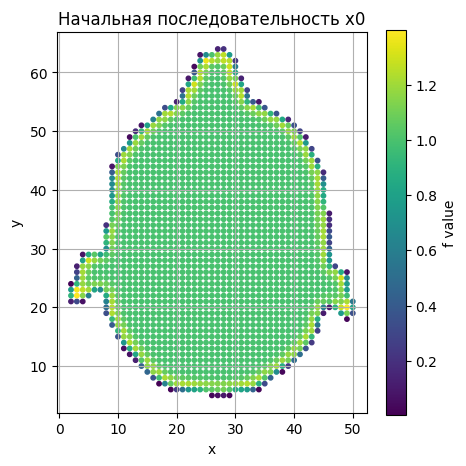

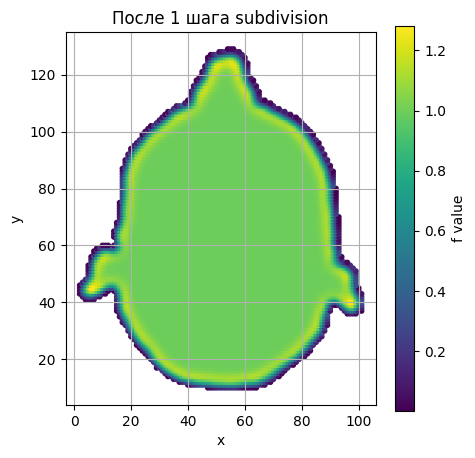

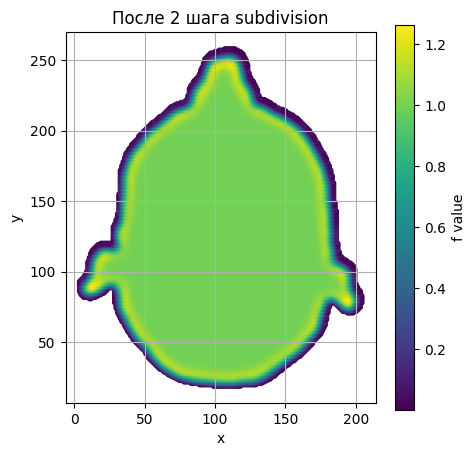

In [123]:
# mask = build_kernel(torch.tensor([1 / 4, 3 / 4, 3 / 4, 1 / 4], dtype=torch.float32), dim = 3)
mask = build_kernel(torch.tensor([1 / 8, 4 / 8, 6 / 8, 4 / 8, 1 / 8], dtype=torch.float32), dim = 3)

slice_coord_start = int(slice_coord/2**j)

plot_subdivision_points(
        x0[:,:,slice_coord_start],
        threshold=0.00,
        title=f"Начальная последовательность x0",
        figsize=(5,5),
        do_ceil= False,
        visual_type= 'scatter'
    )

x0_subdivisioned = x0.clone()
k = 2
for i in range(j):
    x0_subdivisioned = Sub_A_fast(x0_subdivisioned, mask)
    plot_subdivision_points(
        x0_subdivisioned[:,:,slice_coord_start*k],
        threshold=0.00,
        title=f"После {i+1} шага subdivision",
        figsize=(5,5),
        do_ceil= False,
        visual_type= 'scatter'
    )
    k *=2
    # print(k)

In [13]:
# threshold = 0.9

# x0_clone_filtered_ceil = (x0_subdivisioned > threshold).float()
# plot_subdivision_points(data = x0_clone_filtered_ceil[:,:,70*4],
#                         threshold=0.0,
#                         title='',
#                         figsize=(10,10),
#                         do_ceil=False,
#                         visual_type='scatter')

/home/alexander/DIPLOM/.diplom3d/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:37: UserWarning:

Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.



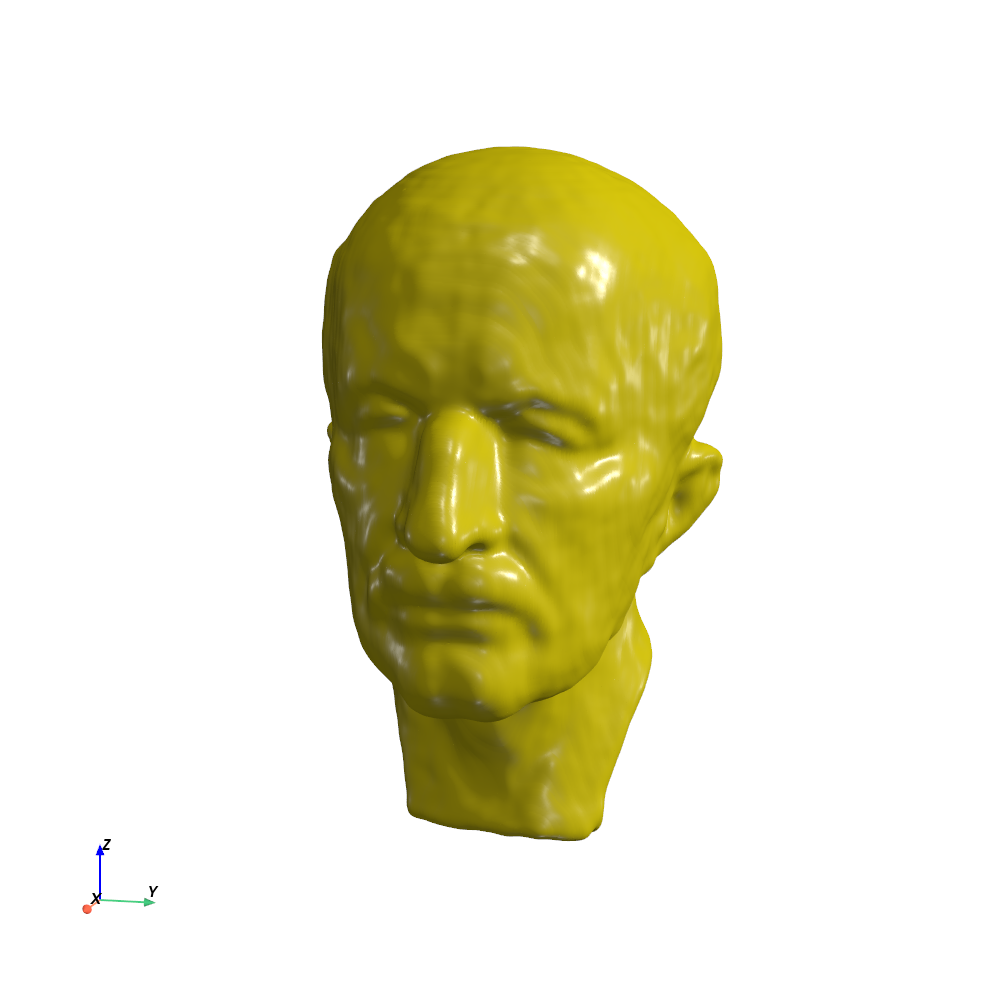

Изображение сохранено в plank/plank_subdivisioned_1_j2_2gd.png


In [130]:
shadows_visual(input_tensor=x0_subdivisioned, 
                name=f"{subfolder}_subdivisioned_{input_koef}_j{j}_{gd_iter}gd", 
                subfolder=subfolder,
                level=0.3,
                ambient = 0.3,
                diffuse = 0.8,
                specular = 1,
                specular_power = 30,
                roughness = 0.3,
                # window_size = (800,800),
                camera_position=camera_position,
                light_position=(50,850,500)
               )